# The Earth: PREM, chords, and slabs

A neutrino crossing the Earth does not see a constant Hamiltonian, so the exact expansions do not apply to its whole trajectory. They apply to any piece over which the density is taken constant — which is what the `earth` and `slabs` modules build.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
import earth
import slabs

## The density profile

PREM is a piecewise-polynomial fit to seismological data. Note the jumps between shells, and that the density is *not* constant within a shell.

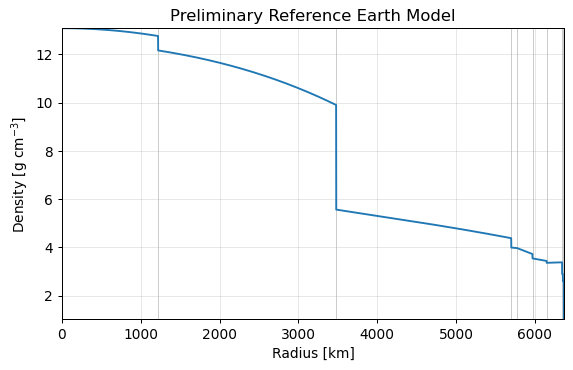

In [3]:
r = np.linspace(0.0, gd.EARTH_RADIUS, 4000)
rho = earth.density_prem(r)

fig, ax = plt.subplots()
ax.plot(r, rho)
for b in earth.PREM_BOUNDARIES:
    ax.axvline(b, color="0.8", lw=0.8, zorder=0)
ax.set_xlabel("Radius [km]")
ax.set_ylabel(r"Density [g cm$^{-3}$]")
ax.set_title("Preliminary Reference Earth Model")
plt.show()

A strong check on the profile: integrating it over the volume of the Earth must give the Earth's mass.

In [4]:
integrand = 4.0*np.pi*(r*1.e5)**2.0*rho
x = r*1.e5
mass_kg = np.sum(0.5*(integrand[1:]+integrand[:-1])*np.diff(x))*1.e-3
print("PREM integrates to  %.4e kg" % mass_kg)
print("the Earth's mass is 5.972e+24 kg")

PREM integrates to  5.9737e+24 kg
the Earth's mass is 5.972e+24 kg


## The chord, and where it crosses shells

A neutrino arriving from below travels a chord set by $\cos\theta_z$. Along it the radius falls to a minimum and rises again, so the chord crosses most shells **twice**.

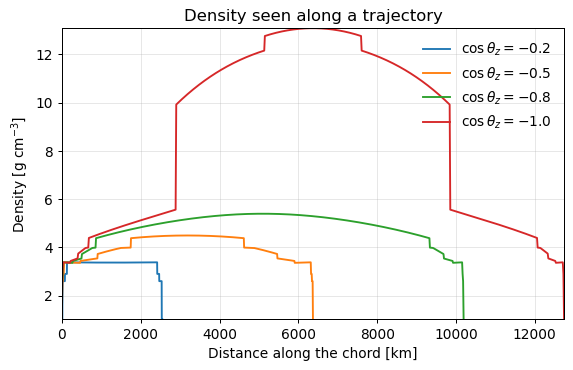

In [5]:
fig, ax = plt.subplots()
for costhz in (-0.2, -0.5, -0.8, -1.0):
    d = earth.distance_traveled_inside_earth(costhz)
    l = np.linspace(0.0, d, 800)
    ax.plot(l, earth.density_prem(
        earth.earth_radial_distance_from_depth(costhz, l)),
        label=r"$\cos\theta_z = %.1f$" % costhz)
ax.set_xlabel("Distance along the chord [km]")
ax.set_ylabel(r"Density [g cm$^{-3}$]")
ax.set_title("Density seen along a trajectory")
ax.legend()
plt.show()

In [6]:
costhz = -1.0
edges = earth.prem_layer_edges_along_chord(costhz)
print("PREM shells:            10")
print("boundary crossings:     %d" % len(edges))
print("chord segments:         %d" % (len(edges)+1))
print("-> a chord enters and leaves each shell it reaches")

PREM shells:            10
boundary crossings:     18
chord segments:         19
-> a chord enters and leaves each shell it reaches


## From chord to slabs

Two different things decide where the slabs are cut. **Between** shells the density jumps, so the chord is split at every boundary crossing. **Within** a shell it varies smoothly, so each segment is divided further into `n_slabs_per_segment` equal sub-slabs with the density taken at the midpoint.

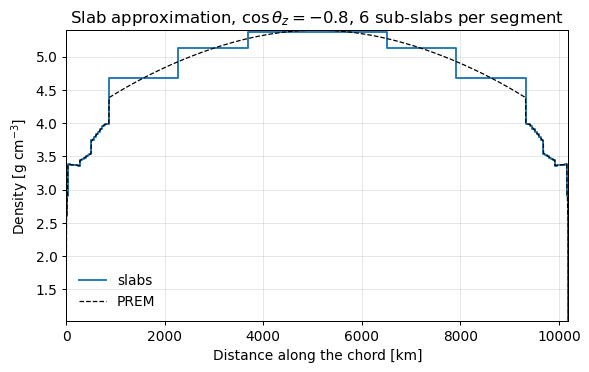

90 slabs, total 10193.6 km


In [7]:
widths, densities = earth.earth_slabs(-0.8, n_slabs_per_segment=6)

fig, ax = plt.subplots()
ax.step(np.concatenate(([0.0], np.cumsum(widths))),
        np.concatenate((densities[:1], densities)),
        where="pre", label="slabs")
l = np.linspace(0.0, widths.sum(), 1500)
ax.plot(l, earth.density_prem(
    earth.earth_radial_distance_from_depth(-0.8, l)),
    "k--", lw=1, label="PREM")
ax.set_xlabel("Distance along the chord [km]")
ax.set_ylabel(r"Density [g cm$^{-3}$]")
ax.set_title(r"Slab approximation, $\cos\theta_z = -0.8$, "
             "6 sub-slabs per segment")
ax.legend()
plt.show()

print("%d slabs, total %.1f km" % (len(widths), widths.sum()))

## From slabs to a probability

The pieces are now in place, and this is where `slabs` earns its name. `earth` gives the widths and densities; `hamiltonians3nu.hamiltonian_3nu_matter` turns each density into a Hamiltonian; and `slabs.probabilities_3nu_slabs` solves each piece exactly and multiplies the evolution operators together, in order.

Nothing here is approximated except the profile itself: the evolution *within* each slab is the same closed form as anywhere else in this library. `earth.probabilities_3nu_earth` is exactly this three-step recipe wrapped up, and doing it by hand once is the way to see what it does — and the way to build a profile of your own, which is what notebook 08 goes on to do.

In [8]:
widths_km, densities = earth.earth_slabs(
    -0.8, n_slabs_per_segment=6)

# One Hamiltonian per slab, from that slab's density
H_slabs = hamiltonians3nu.hamiltonian_3nu_matter(
    H_VAC_3NU, 10.0*GEV,
    earth.matter_potential(densities))

# Solve each exactly, multiply the operators in order
p_by_hand = slabs.probabilities_3nu_slabs(
    H_slabs, widths_km*KM)

# The wrapper that does all three steps for you
p_wrapped = earth.probabilities_3nu_earth(
    H_VAC_3NU, 10.0*GEV, -0.8, n_slabs_per_segment=6)

print("%d slabs, %.0f km total" % (len(widths_km), widths_km.sum()))
print("P_mumu, by hand   = %.9f" % p_by_hand[4])
print("P_mumu, wrapped   = %.9f" % p_wrapped[4])
print("difference        = %.2e"
      % abs(p_by_hand[4] - p_wrapped[4]))

90 slabs, 10194 km total
P_mumu, by hand   = 0.897779313
P_mumu, wrapped   = 0.897779313
difference        = 0.00e+00


Identical, as they must be — the wrapper is the recipe, not a different calculation.

If you need the evolution **operator** across the trajectory rather than the probabilities — to compose it with something else, or to propagate a density matrix — `slabs.evolution_operator_3nu_slabs` returns it from the same inputs.

In [9]:
U = np.array(slabs.evolution_operator_3nu_slabs(
    H_slabs, widths_km*KM))

print("U has shape", U.shape)
print("unitary to      %.2e"
      % np.max(np.abs(U.conj().T @ U - np.eye(3))))
# P_(alpha->beta) = |U_(beta,alpha)|^2
print("|U[1,1]|^2      = %.9f  (= P_mumu above)"
      % abs(U[1, 1])**2)

U has shape (3, 3)
unitary to      3.58e-14
|U[1,1]|^2      = 0.897779313  (= P_mumu above)


## Convergence

The slicing is the only approximation in the whole calculation, so it is worth watching it converge rather than trusting it. Midpoint sampling is second order: past about 32 sub-slabs per segment, each doubling cuts the error by roughly four.

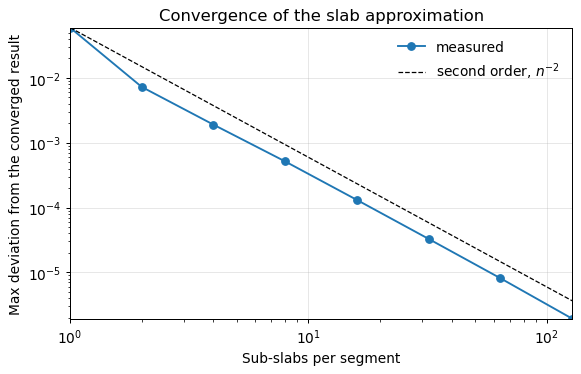

In [10]:
ref = np.array(earth.probabilities_3nu_earth(
    H_VAC_3NU, 10.0*GEV, -0.8, n_slabs_per_segment=512))

ns = [1, 2, 4, 8, 16, 32, 64, 128]
err = [np.max(np.abs(np.array(earth.probabilities_3nu_earth(
           H_VAC_3NU, 10.0*GEV, -0.8, n_slabs_per_segment=n))
       - ref)) for n in ns]

fig, ax = plt.subplots()
ax.loglog(ns, err, "o-", label="measured")
ax.loglog(ns, err[0]*(np.array(ns)/ns[0])**-2.0, "k--", lw=1,
          label=r"second order, $n^{-2}$")
ax.set_xlabel("Sub-slabs per segment")
ax.set_ylabel("Max deviation from the converged result")
ax.set_title("Convergence of the slab approximation")
ax.legend()
plt.show()

---

**Previous:** [Bi-probability plots](05_biprobability.ipynb)  
**Next:** [Probabilities through the Earth](07_earth_probabilities.ipynb) --- zenith-angle scans, an Earth oscillogram, and real baselines  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)